In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision-figures"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)


import pandas as pd
import scanpy as sc

from spatial_tcr.clonal_expansion import find_avbv_clones
from spatial_tcr.plotting import (
    plot_side_by_side_counts,
)
from spatial_tcr.tcr import get_tcr_genes

## Perform analysis on unmerged TRVs


In [ ]:
path = "data/xenium/processed/05.2-kidney_tcr_infilrate.h5ad"
adata = sc.read_h5ad(path)
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 480
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate'
    var: 'n_cells_by_co

In [ ]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)
find_avbv_clones(adata, av_genes, bv_genes, layer="counts")

Found 54 TRAV genes, 61 TRBV genes, 3 TRDV genes, 14 TRGV genes
Found 59365 singlets
Found 14940 multiplets
Found 1595 valid multiplets
Found 67216 singlets
Found 17727 multiplets
Found 1662 valid multiplets
Found 16205 avbv clones


In [ ]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

(54, 1) (54, 1)


<Axes: title={'center': 'TRAV Gene Expression Distribution in Single vs Paired Cells'}, ylabel='Fraction'>

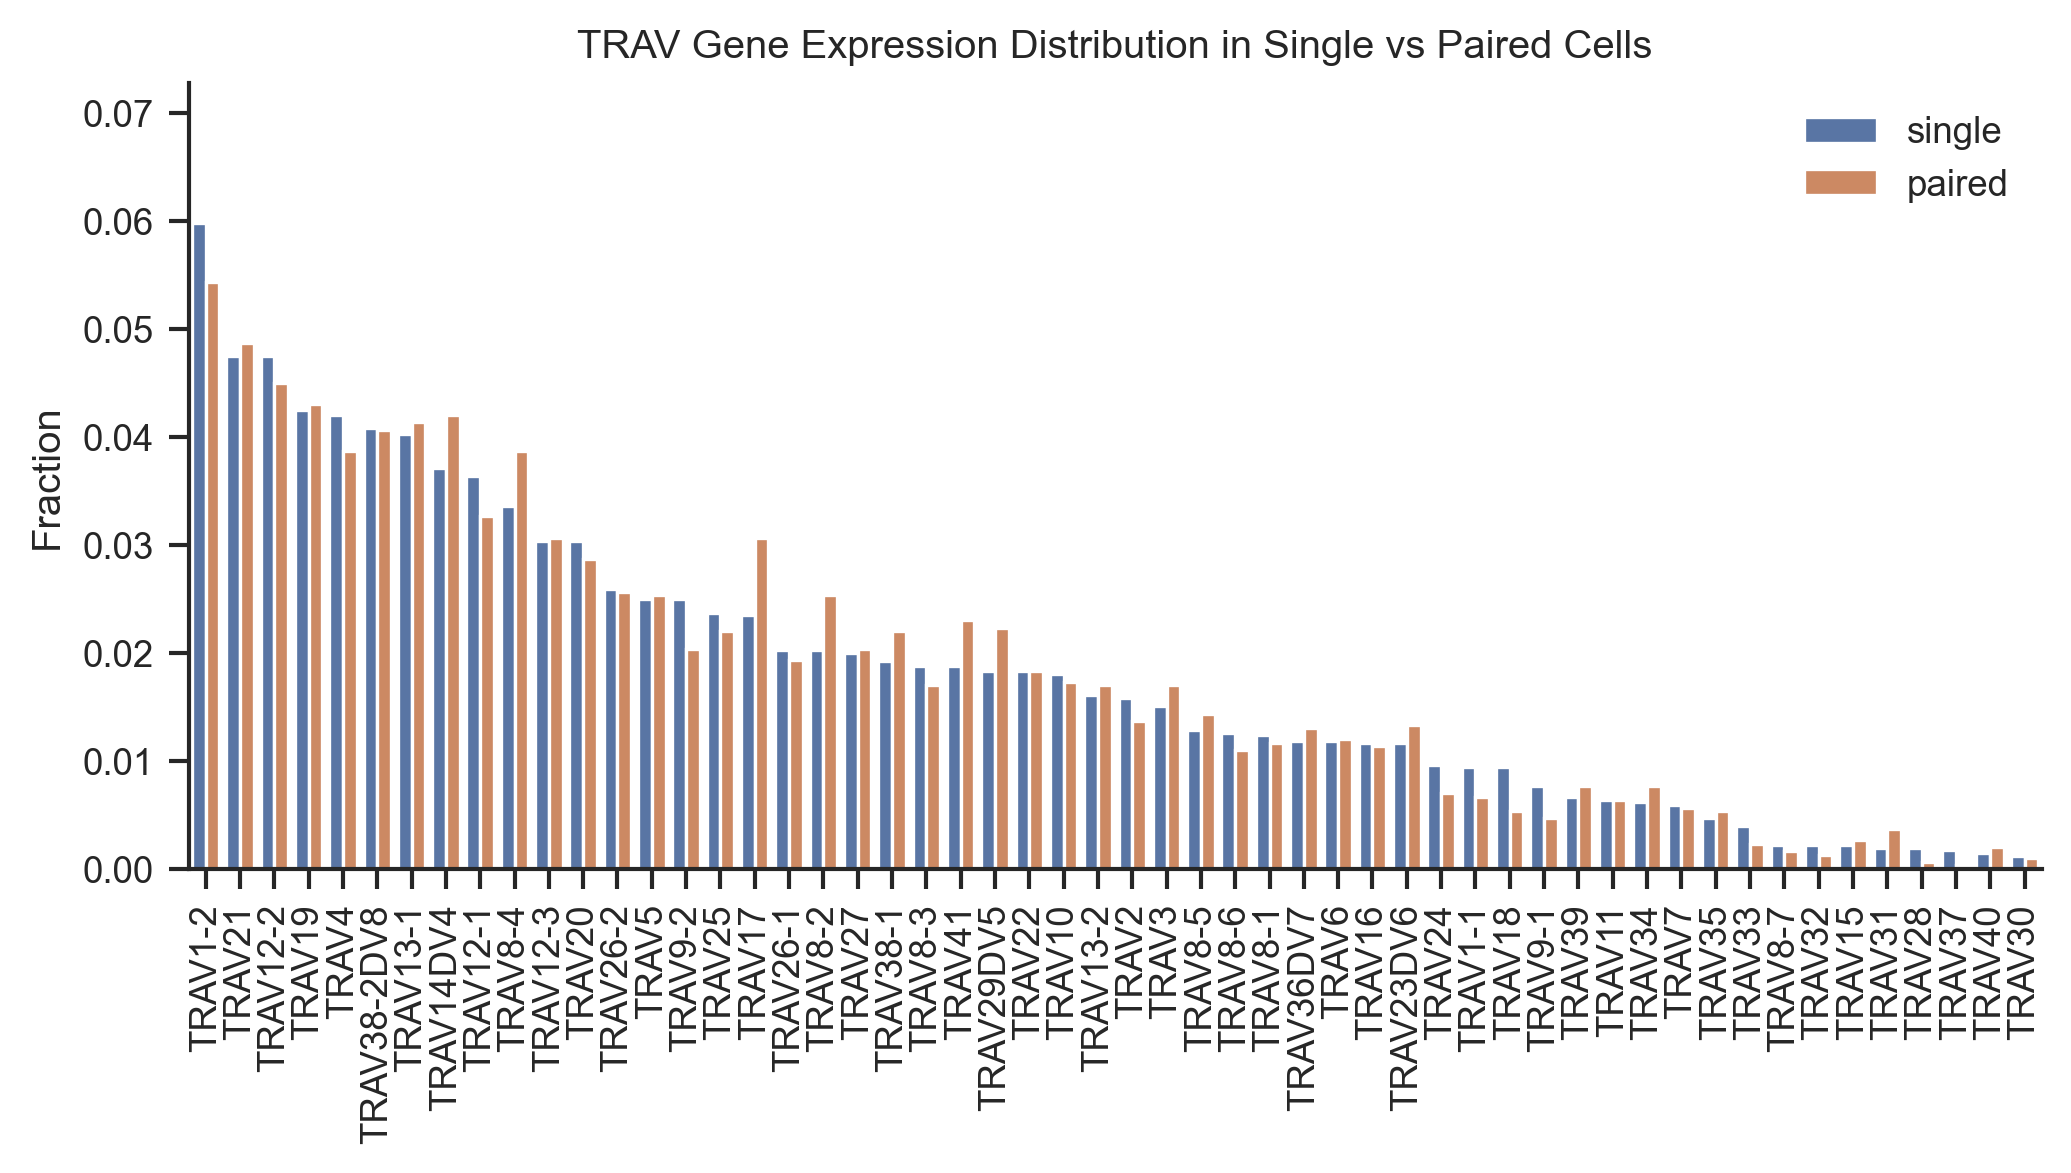

In [ ]:
df_1 = ad_t.obs.loc[ad_t.obs["avbv_clone"].isna(), "av_clone"].value_counts().to_frame()
df_2 = (
    ad_t.obs.loc[~ad_t.obs["avbv_clone"].isna(), "av_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
av_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
av_counts.columns = ["single", "paired"]

plot_side_by_side_counts(
    av_counts,
    normalize=True,
    title="TRAV Gene Expression Distribution in Single vs Paired Cells",
    annotate_per_category=False,
    figsize=(7, 4),
)

(61, 1) (61, 1)


<Axes: title={'center': 'TRBV Gene Expression Distribution in Single vs Paired Cells'}, ylabel='Fraction'>

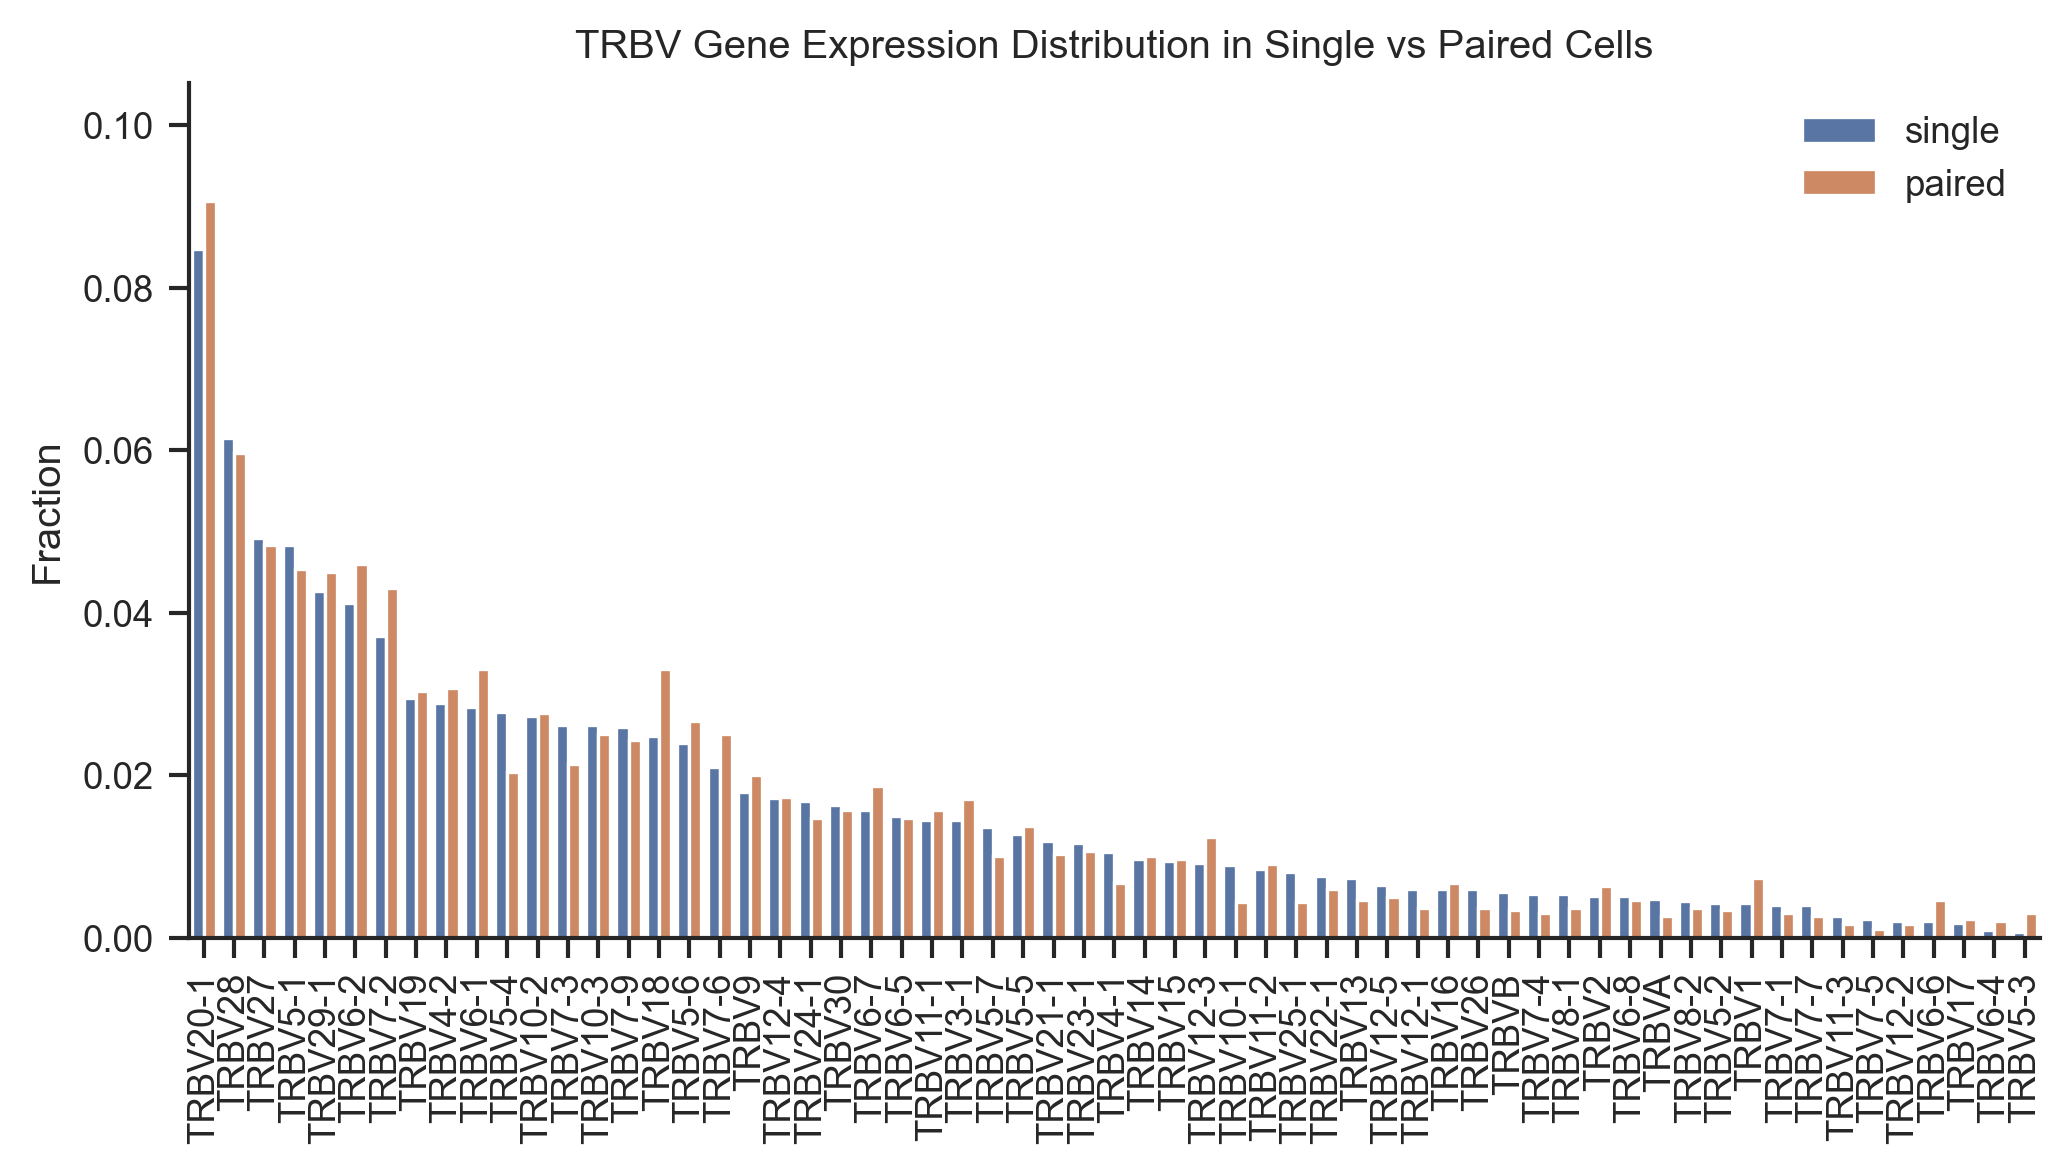

In [ ]:
df_1 = ad_t.obs.loc[ad_t.obs["avbv_clone"].isna(), "bv_clone"].value_counts().to_frame()
df_2 = (
    ad_t.obs.loc[~ad_t.obs["avbv_clone"].isna(), "bv_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
bv_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
bv_counts.columns = ["single", "paired"]

plot_side_by_side_counts(
    bv_counts,
    normalize=True,
    title="TRBV Gene Expression Distribution in Single vs Paired Cells",
    annotate_per_category=False,
    figsize=(7, 4),
)